In [1]:
import math
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import wandb
from wandb.apis.public.runs import Run

In [2]:
api = wandb.Api()

In [3]:
runs = api.runs(
    "graphcore/llama-mobile",
    filters={"config.name": "base-model-27-02-26", "state": "finished"},
)

In [4]:
# Return (metric, relaxed_metric)
def get_metrics(task: str) -> tuple[str]:
    from eval.vqa import TASKS

    metrics, relaxed_metrics = TASKS[task].METRICS, TASKS[task].RELAXED_METRICS
    assert len(metrics) == 1 and len(relaxed_metrics) == 1
    return (metrics[0], relaxed_metrics[0])


def cleanup_run(run: Run) -> dict[str, Any] | None:
    d = {}
    d["name"] = run.name
    d["n_steps"] = run.config["training"]["n_steps"]
    d["lr_exponent"] = math.log2(run.config["training"]["optimiser"]["lr"])

    for task in ["vqa", "ai2d", "chartqa", "docvqa"]:
        m, relaxed_m = get_metrics(task)
        d[task] = run.summary[f"downstream.{task}.{m}"]
        d[f"{task}_relaxed"] = run.summary[f"downstream.{task}.{relaxed_m}"]

    history = run.history()
    d["train_loss"] = (
        np.mean(history["train/loss"].tail(10).values)
        if "train/loss" in history
        else None
    )
    d["val_loss"] = run.summary["val/loss"] if "val/loss" in run.summary else None

    return d

In [5]:
df = pd.DataFrame([cleanup_run(run) for run in runs])

In [6]:
df.sort_values(by=["n_steps", "lr_exponent"], ascending=True, inplace=True)
df = df.drop_duplicates()

In [7]:
df

,name,n_steps,lr_exponent,vqa,vqa_relaxed,ai2d,ai2d_relaxed,chartqa,chartqa_relaxed,docvqa,docvqa_relaxed,train_loss,val_loss
4,silvery-sun-1657,256,-18.0,0.277344,0.370768,0.013672,0.208984,0.003906,0.395508,0,0.383789,0.037964,0.050335
7,eternal-serenity-1660,256,-17.0,0.237305,0.294596,0.000977,0.076172,0.001953,0.291016,0,0.189453,0.034596,0.046428
9,leafy-durian-1662,512,-18.0,0.420898,0.555664,0.015625,0.265625,0.003906,0.527344,0,0.433594,0.029822,0.038704
2,peach-leaf-1655,512,-17.0,0.305013,0.402995,0.001953,0.116211,0.001953,0.493164,0,0.216797,0.027958,0.036271
0,graceful-paper-1653,512,-16.0,0.241536,0.315104,0.000000,0.044922,0.000000,0.215820,0,0.384766,0.028844,0.038078
10,light-lake-1663,1024,-18.0,0.506510,0.632812,0.043945,0.397461,0.008789,0.563477,0,0.535156,0.021645,0.030847
1,unique-glitter-1654,1024,-17.0,0.308268,0.436198,0.039062,0.291992,0.003906,0.519531,0,0.253906,0.021132,0.030197
8,dauntless-durian-1661,1024,-16.0,0.339844,0.472005,0.016602,0.022461,0.002930,0.305664,0,0.281250,0.021820,0.031207
6,leafy-rain-1659,2048,-18.0,0.495768,0.656576,0.103516,0.208984,0.011719,0.592773,0,0.479492,0.018231,0.025381
3,crimson-firebrand-1656,2048,-17.0,0.421875,0.541667,0.144531,0.360352,0.001953,0.563477,0,0.395508,0.017792,0.024940


In [8]:
# TODO: Baseline runs

# baseline_runs = runs = api.runs(
#     "graphcore/llama-mobile",
#     filters={"config.name": "baseline-12-02-26", "state": "finished"},
# )
# baseline = {}
# step_0 = {}

# for run in runs:
#     # Check I'm using the right quantisation for step = 0 baseline
#     if run.config["quantisation"] == runs[0].config["quantisation"]:
#         assert run.config["training"]["n_steps"] == 0
#         for task in ["ai2d", "chartqa", "docvqa", "vqa"]:
#             m, relaxed_m = get_metrics(task)
#             step_0[task] = (
#                 run.summary[f"downstream.{task}.{m}"],
#                 run.summary[f"downstream.{task}.{relaxed_m}"],
#             )

#     # bfloat16 baseline
#     if (
#         run.config["quantisation"]["fmt"]["_type"] == "torch"
#         and run.config["quantisation"]["fmt"]["dtype"] == "bfloat16"
#     ):
#         for task in ["ai2d", "chartqa", "docvqa", "vqa"]:
#             m, relaxed_m = get_metrics(task)
#             baseline[task] = (
#                 run.summary[f"downstream.{task}.{m}"],
#                 run.summary[f"downstream.{task}.{relaxed_m}"],
#             )

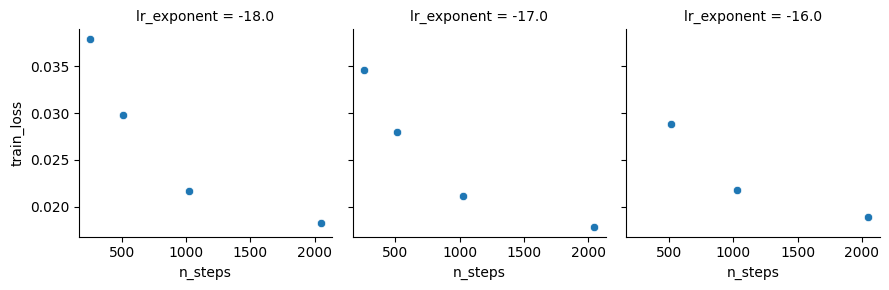

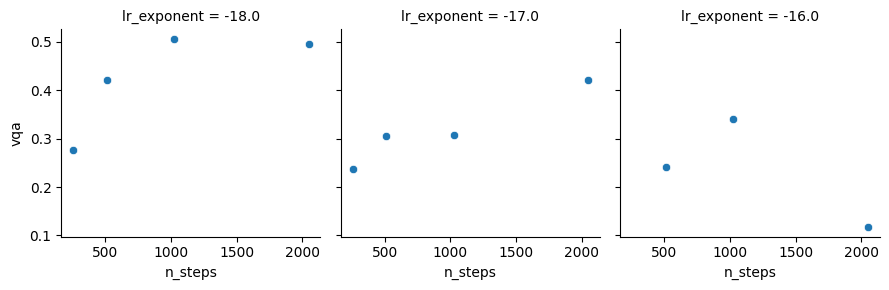

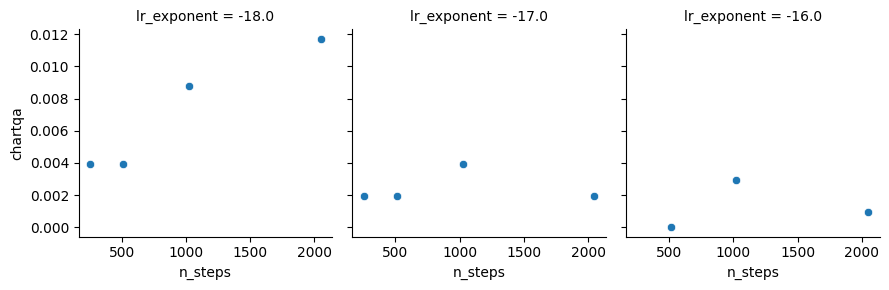

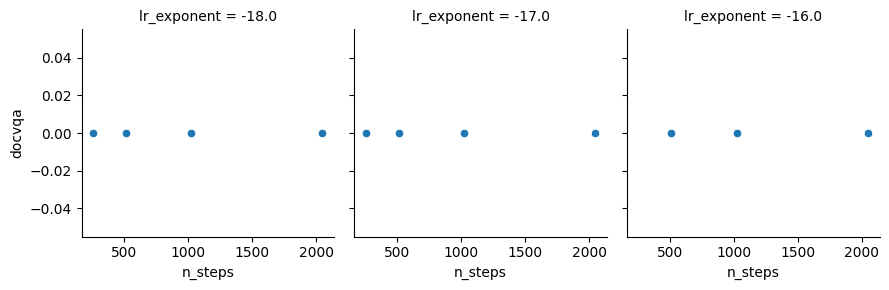

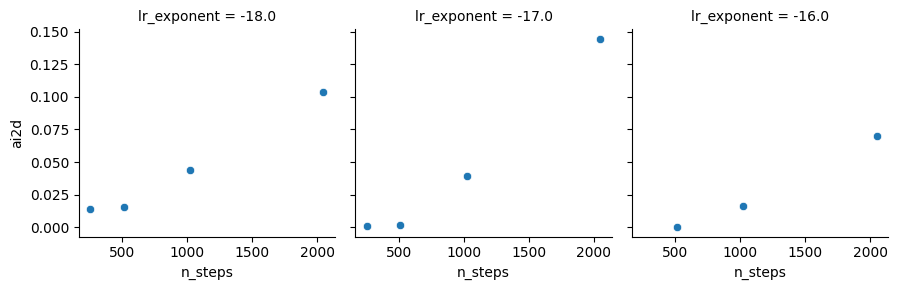

In [9]:
g = sns.relplot(data=df, x="n_steps", y="train_loss", col="lr_exponent", height=3)

tasks = ["vqa", "chartqa", "docvqa", "ai2d"]
for task in tasks:
    g = sns.relplot(data=df, x="n_steps", y=task, col="lr_exponent", height=3)
    # for ax in g.axes.flat:
    #     ax.axhline(step_0[task][0], linestyle="--", color="black")
    #     ax.axhline(baseline[task][0], linestyle="--", color="black")

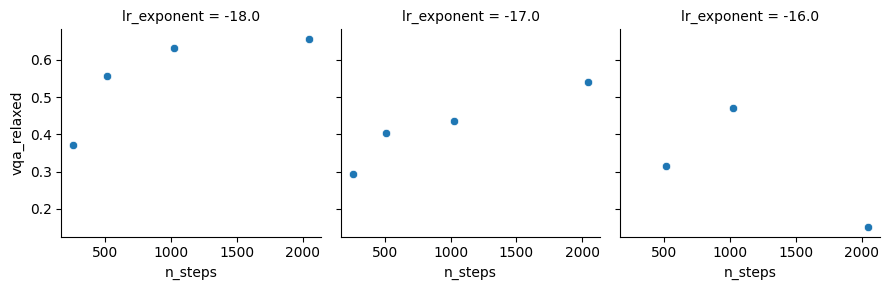

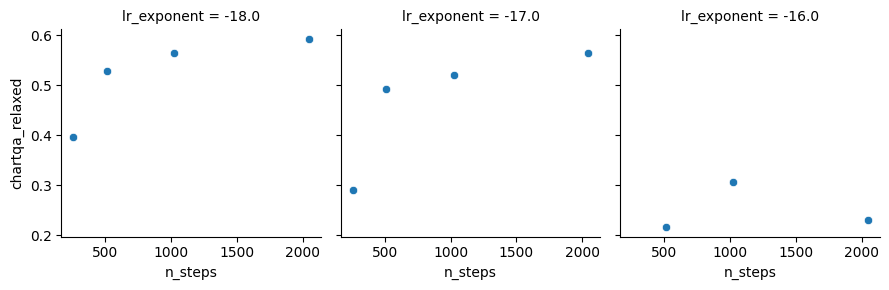

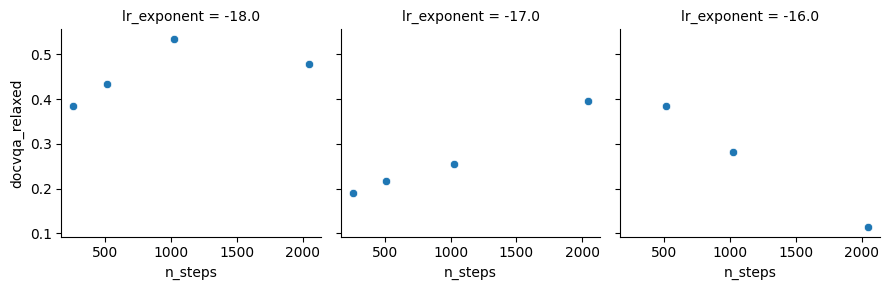

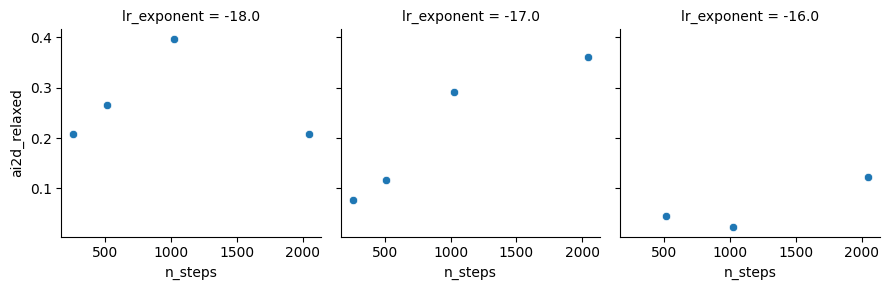

In [10]:
tasks = ["vqa", "chartqa", "docvqa", "ai2d"]
for task in tasks:
    g = sns.relplot(data=df, x="n_steps", y=f"{task}_relaxed", col="lr_exponent", height=3)
    # for ax in g.axes.flat:
    #     ax.axhline(step_0[task][1], linestyle="--", color="black")
    #     ax.axhline(baseline[task][1], linestyle="--", color="black")

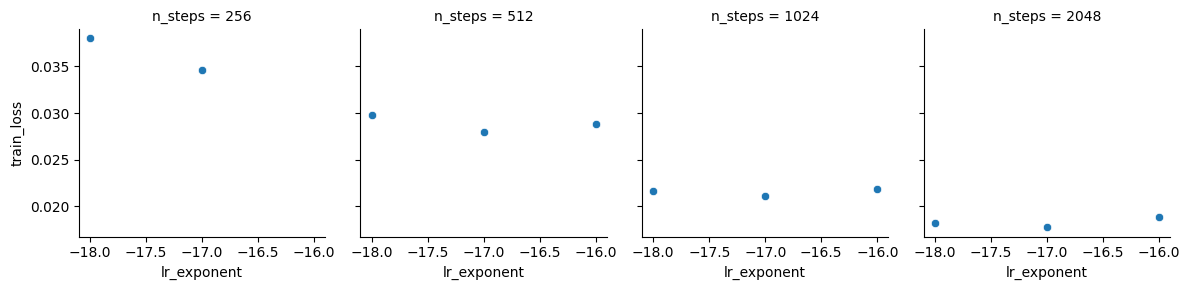

In [11]:
sns.relplot(data=df, x="lr_exponent", y="train_loss", col="n_steps", height=3)

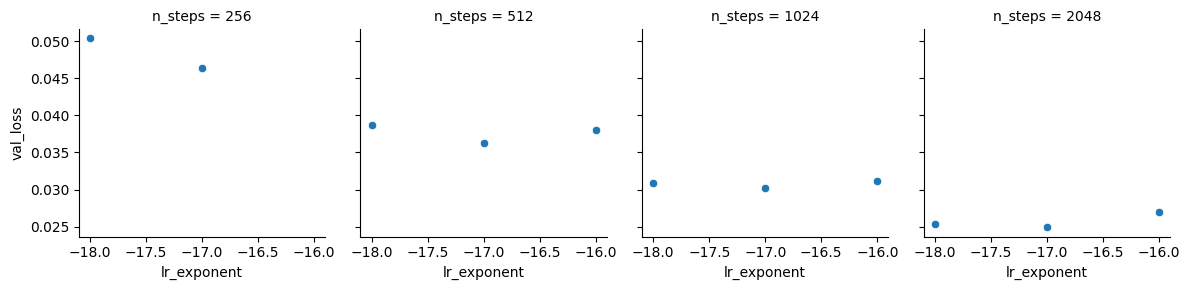

In [12]:
sns.relplot(data=df, x="lr_exponent", y="val_loss", col="n_steps", height=3)